# U-Net tile restoration (damaged → undamaged)
Authors:
- Matteo COUCHOUD
- Marta SHKRELI
- Naël ARNOUX

This notebook trains a small U-Net to restore damaged tiles into their undamaged targets.

Tiles are stored by their x,y positions in a folder named after the original image ID (generated in `image_spliter.ipynb`).\
**Filename rule**: `IMGID_X_Y.png`  
- `IMGID` = 3-digit artwork id (also the folder name)  
- `X` = tile x position  
- `Y` = tile y position  

**Expected tile set structure**:
```
tiledsets/
  train_indexed_images/
    damaged/<IMGID>/*.png
    undamaged/<IMGID>/*.png
  eval_indexed_images/
    damaged/<IMGID>/*.png
    undamaged/<IMGID>/*.png
```


In [50]:

!pip install torch torchvision pillow numpy matplotlib


In [51]:
import os
import re
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn.functional as F

print("PyTorch:", torch.__version__)


PyTorch: 2.10.0


Searching for the device type is necessary so the training uses the right resources.

In [52]:
def get_device() -> torch.device:
    # macOS: uses MPS if available (Apple Silicon)
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = get_device()
print("Device:", device)


Device: mps


## Training Configuration

In [53]:
@dataclass
class Config:
    root: str = "tiledsets"
    train_split: str = "train_indexed_images"
    val_split: str = "eval_indexed_images"
    epochs: int = 20
    batch_size: int = 64
    lr: float = 2e-4
    weight_decay: float = 1e-4
    num_workers: int = 0
    save_path: str = "unet_tiles64_best.pt"
    tile_size=128

cfg = Config()
cfg


Config(root='tiledsets', train_split='train_indexed_images', val_split='eval_indexed_images', epochs=20, batch_size=64, lr=0.0002, weight_decay=0.0001, num_workers=0, save_path='unet_tiles64_best.pt')

## Dataset (paired by key: IMGID, X, Y)
We build an index of tiles from `damaged/` and `undamaged/` and pair by the parsed key `(imgid, x, y)`.

In [54]:
TILE_RE = re.compile(r"^(?P<imgid>\d{3})_(?P<x>\d+)_(?P<y>\d+)\.(png|jpg|jpeg)$", re.IGNORECASE)

Key = Tuple[str, int, int]  # (imgid, x, y)

def pil_to_tensor(img: Image.Image) -> torch.Tensor:
    # RGB -> float tensor in [0,1], (C,H,W)
    arr = np.array(img, dtype="uint8")
    if arr.ndim == 2:
        arr = arr[..., None]
    t = torch.from_numpy(arr).permute(2, 0, 1).contiguous().float() / 255.0
    return t

def index_tiles(folder: Path) -> Dict[Key, Path]:
    idx: Dict[Key, Path] = {}
    for p in folder.rglob("*"):
        if not p.is_file():
            continue
        m = TILE_RE.match(p.name)
        if not m:
            continue
        imgid = m.group("imgid")
        x = int(m.group("x"))
        y = int(m.group("y"))
        # Sanity: folder name equals imgid, e.g. damaged/005/005_0_2.png
        if p.parent.name != imgid:
            continue
        idx[(imgid, x, y)] = p
    return idx

class PairedTilesByKey(Dataset):
    """Returns (damaged, target) tensors in [0,1], shape (3,64,64)."""

    def __init__(self, root: str, split: str, return_meta: bool = False, tile_size: int = 128):
        self.root = Path(root)
        self.split = split
        self.return_meta = return_meta
        self.tile_size=tile_size

        dmg_dir = self.root / split / "damaged"
        und_dir = self.root / split / "undamaged"
        if not dmg_dir.exists():
            raise FileNotFoundError(f"Missing: {dmg_dir}")
        if not und_dir.exists():
            raise FileNotFoundError(f"Missing: {und_dir}")

        dmg_idx = index_tiles(dmg_dir)
        und_idx = index_tiles(und_dir)

        self.keys: List[Key] = sorted(set(dmg_idx.keys()) & set(und_idx.keys()))
        if not self.keys:
            raise RuntimeError("No paired tiles found by (imgid,x,y). Check structure/names.")

        self.dmg_idx = dmg_idx
        self.und_idx = und_idx

    def __len__(self) -> int:
        return len(self.keys)

    def __getitem__(self, i: int):
        key = self.keys[i]
        dp = self.dmg_idx[key]
        up = self.und_idx[key]

        damaged = Image.open(dp).convert("RGB")
        target  = Image.open(up).convert("RGB")

        # Force a constant size so batching works
        if damaged.size != (self.tile_size, self.tile_size):
            damaged = damaged.resize((self.tile_size, self.tile_size), Image.BICUBIC)
        if target.size != (self.tile_size, self.tile_size):
            target = target.resize((self.tile_size, self.tile_size), Image.BICUBIC)

        x = pil_to_tensor(damaged)
        y = pil_to_tensor(target)

        if self.return_meta:
            imgid, tx, ty = key
            return x, y, imgid, tx, ty
        return x, y


## DataLoaders
We use parallel workers to make computation faster.
- `num_workers`: parallel PNG decoding / loading
- `persistent_workers=True`: keeps workers alive across epochs
- `prefetch_factor`: each worker preloads batches

In [55]:
def make_loader(ds: Dataset, batch_size: int, train: bool, num_workers: int) -> DataLoader:
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=train,
        drop_last=train,
        num_workers=num_workers,
        persistent_workers=(num_workers > 0),
        prefetch_factor=4 if num_workers > 0 else None,
        pin_memory=torch.cuda.is_available(),  # only useful on CUDA
    )

train_ds = PairedTilesByKey(cfg.root, cfg.train_split, return_meta=False, tile_size=cfg.tile_size)
val_ds   = PairedTilesByKey(cfg.root, cfg.val_split, return_meta=False, tile_size=cfg.tile_size)

train_loader = make_loader(train_ds, cfg.batch_size, train=True,  num_workers=cfg.num_workers)
val_loader   = make_loader(val_ds,   cfg.batch_size, train=False, num_workers=cfg.num_workers)

print("Train pairs:", len(train_ds))
print("Val pairs:", len(val_ds))


Train pairs: 4258
Val pairs: 1329


## U-Net model Configuration

In [56]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

class UNetSmall(nn.Module):
    def __init__(self, in_ch: int = 3, out_ch: int = 3, base: int = 64):
        super().__init__()
        self.pool = nn.MaxPool2d(2)

        self.enc1 = ConvBlock(in_ch, base)
        self.enc2 = ConvBlock(base, base * 2)
        self.enc3 = ConvBlock(base * 2, base * 4)

        self.mid = ConvBlock(base * 4, base * 8)

        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, 2, stride=2)
        self.dec3 = ConvBlock(base * 8, base * 4)

        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, 2, stride=2)
        self.dec2 = ConvBlock(base * 4, base * 2)

        self.up1 = nn.ConvTranspose2d(base * 2, base, 2, stride=2)
        self.dec1 = ConvBlock(base * 2, base)

        self.out = nn.Conv2d(base, out_ch, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        m = self.mid(self.pool(e3))

        d3 = self.up3(m)
        d3 = F.interpolate(d3, size=e3.shape[-2:], mode="nearest")  # <-- added
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        d2 = F.interpolate(d2, size=e2.shape[-2:], mode="nearest")  # <-- added
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = F.interpolate(d1, size=e1.shape[-2:], mode="nearest")  # <-- added
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return torch.sigmoid(self.out(d1))  # output in [0,1]

model = UNetSmall(in_ch=3, out_ch=3, base=64).to(device)
sum(p.numel() for p in model.parameters())


7703107

## Training
Here we use **L1 loss** and AdamW.

(As we tested the code on different hardware, we have the different scalers bellow:)
- On CUDA: uses AMP (mixed precision) automatically
- On macOS MPS: trains in FP32 for stability

In [57]:
def train_one_epoch(model, loader, opt, device, use_amp: bool):
    model.train()
    l1 = nn.L1Loss()
    running = 0.0

    scaler = torch.amp.GradScaler("cuda", enabled=use_amp) if use_amp else None

    for x, y in loader:
        x = x.to(device, non_blocking=torch.cuda.is_available())
        y = y.to(device, non_blocking=torch.cuda.is_available())

        opt.zero_grad(set_to_none=True)

        if use_amp:
            with torch.cuda.amp.autocast():
                pred = model(x)
                loss = l1(pred, y)
            scaler.scale(loss).backward()
            scaler.step(opt)
            scaler.update()
        else:
            pred = model(x)
            loss = l1(pred, y)
            loss.backward()
            opt.step()

        running += loss.item() * x.size(0)

    return running / len(loader.dataset)

@torch.no_grad()
def eval_one_epoch(model, loader, device):
    model.eval()
    l1 = nn.L1Loss()
    running = 0.0
    for x, y in loader:
        x = x.to(device, non_blocking=torch.cuda.is_available())
        y = y.to(device, non_blocking=torch.cuda.is_available())
        pred = model(x)
        loss = l1(pred, y)
        running += loss.item() * x.size(0)
    return running / len(loader.dataset)

use_amp = (device.type == "cuda")
opt = AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

best_val = float("inf")
history = {"train_l1": [], "val_l1": []}


In [58]:
for epoch in range(1, cfg.epochs + 1):
    tr = train_one_epoch(model, train_loader, opt, device, use_amp=use_amp)
    va = eval_one_epoch(model, val_loader, device)

    history["train_l1"].append(tr)
    history["val_l1"].append(va)

    print(f"Epoch {epoch:03d}/{cfg.epochs} | train L1 {tr:.5f} | val L1 {va:.5f}")

    if va < best_val:
        best_val = va
        torch.save(
            {"model": model.state_dict(), "epoch": epoch, "val_l1": va, "config": cfg.__dict__},
            cfg.save_path,
        )
        print(f"  ✓ saved best -> {cfg.save_path}")


Epoch 001/20 | train L1 0.15581 | val L1 0.13723
  ✓ saved best -> unet_tiles64_best.pt
Epoch 002/20 | train L1 0.13507 | val L1 0.12530
  ✓ saved best -> unet_tiles64_best.pt
Epoch 003/20 | train L1 0.13102 | val L1 0.12229
  ✓ saved best -> unet_tiles64_best.pt
Epoch 004/20 | train L1 0.12764 | val L1 0.12237
Epoch 005/20 | train L1 0.12601 | val L1 0.11874
  ✓ saved best -> unet_tiles64_best.pt
Epoch 006/20 | train L1 0.12164 | val L1 0.12123
Epoch 007/20 | train L1 0.12115 | val L1 0.12344
Epoch 008/20 | train L1 0.11908 | val L1 0.12160
Epoch 009/20 | train L1 0.11851 | val L1 0.12264
Epoch 010/20 | train L1 0.11550 | val L1 0.12398
Epoch 011/20 | train L1 0.11464 | val L1 0.12340
Epoch 012/20 | train L1 0.11294 | val L1 0.12062
Epoch 013/20 | train L1 0.11116 | val L1 0.12423
Epoch 014/20 | train L1 0.11105 | val L1 0.12166
Epoch 015/20 | train L1 0.11089 | val L1 0.12250
Epoch 016/20 | train L1 0.10828 | val L1 0.12707
Epoch 017/20 | train L1 0.10737 | val L1 0.12745
Epoch 018/2

## Training curves

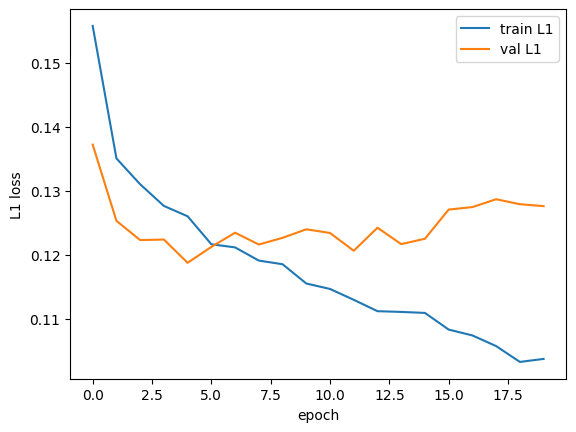

In [59]:
plt.figure()
plt.plot(history["train_l1"], label="train L1")
plt.plot(history["val_l1"], label="val L1")
plt.xlabel("epoch")
plt.ylabel("L1 loss")
plt.legend()
plt.show()


## Qualitative Check
Here we perform a reconstruction on some images then display them to judge the quality of model predictions.

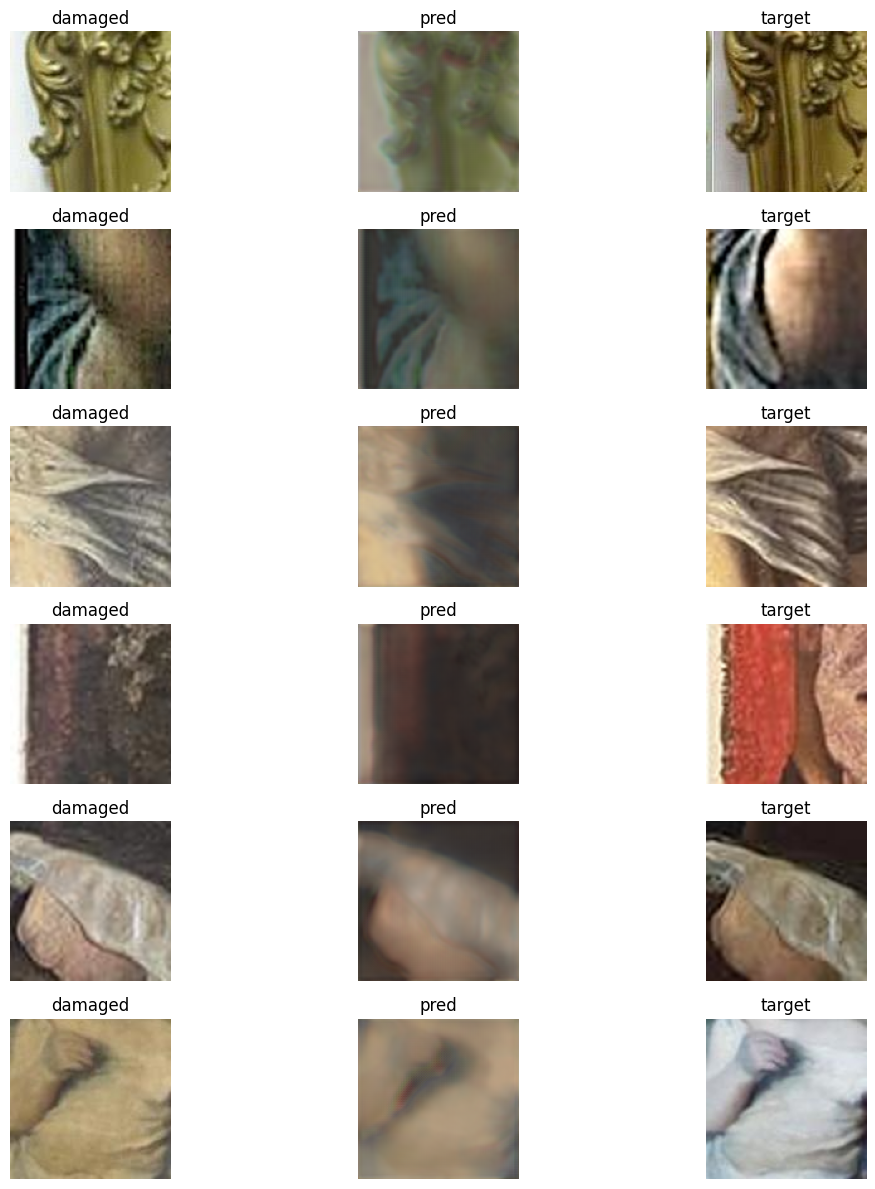

In [60]:
@torch.no_grad()
def show_samples(model, ds: Dataset, device, n: int = 6):
    model.eval()
    idxs = np.random.choice(len(ds), size=min(n, len(ds)), replace=False)

    plt.figure(figsize=(12, 2 * len(idxs)))
    row = 0
    for i in idxs:
        x, y = ds[i]
        x = x.unsqueeze(0).to(device)
        pred = model(x).squeeze(0).cpu()

        damaged = x.squeeze(0).cpu()
        target = y.cpu()

        # (C,H,W)->(H,W,C)
        def chw_to_hwc(t): 
            return t.permute(1,2,0).clamp(0,1).numpy()

        for col, (img, title) in enumerate([(damaged, "damaged"), (pred, "pred"), (target, "target")]):
            ax = plt.subplot(len(idxs), 3, row * 3 + col + 1)
            ax.imshow(chw_to_hwc(img))
            ax.set_title(title)
            ax.axis("off")
        row += 1
    plt.tight_layout()
    plt.show()

show_samples(model, val_ds, device, n=6)


## Load the best checkpoint later

In [61]:
ckpt = torch.load(cfg.save_path, map_location="cpu")
model.load_state_dict(ckpt["model"])
model.to(device)
print("Loaded checkpoint from epoch", ckpt["epoch"], "val_l1", ckpt["val_l1"])


Loaded checkpoint from epoch 5 val_l1 0.1187369154641465


In [2]:
!pip install skimage

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [3 lines of output]
      
      *** Please install the `scikit-image` package (instead of `skimage`) ***
      
      [end of output]
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
ERROR: Failed to build 'skimage' when getting requirements to build wheel


In [ ]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import numpy as np
import torch

def benchmark_model_quantitative(model, loader, device):
    model.eval()
    psnr_scores = []
    ssim_scores = []
    
    print(f"Calcul des métriques sur {len(loader.dataset)} images de test...")
    
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            
            # Dénormalisation : on repasse de [-1, 1] à [0, 1]
            outputs = (outputs * 0.5 + 0.5).clamp(0, 1).cpu().numpy()
            targets = (targets * 0.5 + 0.5).cpu().numpy()
            
            # Calcul pour chaque image du batch
            batch_size = outputs.shape[0]
            for i in range(batch_size):
                # Format (H, W, C) nécessaire pour ces métriques
                img_pred = np.moveaxis(outputs[i], 0, -1)
                img_true = np.moveaxis(targets[i], 0, -1)
                
                # data_range=1.0 car les pixels sont entre 0 et 1
                p = psnr(img_true, img_pred, data_range=1.0)
                s = ssim(img_true, img_pred, data_range=1.0, channel_axis=2)
                
                psnr_scores.append(p)
                ssim_scores.append(s)
    
    print("\n" + "="*30)
    print(f" RÉSULTATS QUANTITATIFS (U-NET)")
    print("="*30)
    print(f"PSNR Moyen : {np.mean(psnr_scores):.2f} dB (Plus c'est haut, mieux c'est)")
    print(f"SSIM Moyen : {np.mean(ssim_scores):.4f}    (Max = 1.0)")
    print("="*30)

# Lancer le calcul
benchmark_model_quantitative(unet, test_loader, device)

## Evaluation

In [ ]:
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

def benchmark_unet_direct():
    """
    Evaluates the U-Net model performance on the validation dataset.
    Assumes 'model' and 'val_ds' are already defined in the environment.
    """
    print(f"Starting evaluation on {len(val_ds)} images...")
    
    # Device configuration
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    
    psnr_scores = []
    ssim_scores = []
    
    # Evaluation Loop (Direct access to dataset)
    with torch.no_grad():
        for i in range(len(val_ds)):
            # Retrieve single image and target tuple from the dataset
            inputs, targets = val_ds[i]
            
            # Add batch dimension: (C, H, W) -> (1, C, H, W)
            inputs = inputs.unsqueeze(0).to(device)
            targets = targets.unsqueeze(0).to(device)
            
            # Inference
            output = model(inputs)
            
            # Denormalize: Convert from [-1, 1] range back to [0, 1]
            img_pred = (output * 0.5 + 0.5).clamp(0, 1).cpu().numpy()[0] 
            img_true = (targets * 0.5 + 0.5).cpu().numpy()[0]
            
            # Permute dimensions for Scikit-Image: (C, H, W) -> (H, W, C)
            img_pred = np.moveaxis(img_pred, 0, -1)
            img_true = np.moveaxis(img_true, 0, -1)
            
            # Calculate Metrics
            p = psnr(img_true, img_pred, data_range=1.0)
            s = ssim(img_true, img_pred, data_range=1.0, channel_axis=2)
            
            psnr_scores.append(p)
            ssim_scores.append(s)
            
            # Progress update every 100 images
            if i > 0 and i % 100 == 0:
                print(f"   -> Processed {i}/{len(val_ds)} images...")

    # Display Final Results
    print("\n" + "="*40)
    print(f" U-NET QUANTITATIVE RESULTS")
    print("="*40)
    print(f"Average PSNR: {np.mean(psnr_scores):.2f} dB")
    print(f"Average SSIM: {np.mean(ssim_scores):.4f}")
    print("="*40)

# Run the benchmark
benchmark_unet_direct()